# 13 Output angle from video

Every degree number in this series so far comes from the servo itself. Cal finds the two stops and
calls the travel between them 183.5 degrees, using the counted gear ratio and the motor revolutions
it counts on the way. The position table bends the pot into a straight line, using the ripple
tracker as its ruler. Both of those are the servo grading its own homework. Nothing has ever looked
at the horn from the outside and said where it actually is.

This notebook builds the outside ruler. I glue a printed tag on the horn and another one beside it,
film them straight down the shaft with an iPhone, and read the horn angle off every frame. The
target is 0.05 to 0.1 degree, which is a little better than one pot count (the MG90 reads about 19
counts per degree).

The capture has not happened yet. So this notebook does two things right now.

1. It proves the measurement on frames rendered with a known answer: a tilted camera, lens
   distortion, the horn sitting above the reference, sensor noise. If the pipeline cannot get the
   angle back out of those to 0.02 degree, it has no business grading a pot.
2. It runs the grading code end to end on a made-up stand-in for the capture, so the day the real
   video lands, section 6 only needs the files swapped in. Every result in section 6 is labelled
   DRY RUN until then.

The video tools live in `oscnb/fiducial.py`, the renderer in `oscnb/fiducial_synth.py`, the printed
sheets come from `python -m oscnb.fiducial_print`, and `tests/test_fiducial.py` pins the 0.02 degree
claims below.

## Picking a rig

The servo is the MG90 on rev 2A board #1. The table being graded is the one `osc lut build` made from
the governed session, `pos-lut-built.json`. Cal's numbers come from the `osc cal` run SAVEd on this
board. The bench script dumps the control table at the start of the capture, and section 6 reads
cal's numbers from that dump once it exists.

In [1]:
import json
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

import oscnb
from oscnb import fiducial as fd, fiducial_synth as sy, poslut

ds = oscnb.use("mg90-a__dev-v006-2A__2s__limit")
servo = oscnb.current().servo
# the table under test, on the firmware's 16-count grid
LUT_PATH = ds.path / "pos-lut-built.json"
LUT = poslut.GridLut.from_json(LUT_PATH.read_text())
LUT_STOPS = json.loads(LUT_PATH.read_text())
# cal on rev 2A board #1, SAVEd: the stops and the travel it calls them
CAL = {"raw_min": 283, "raw_max": 3829, "travel_deg": 183.5, "gear_ratio": 308.05}
assert (LUT_STOPS["raw_min"], LUT_STOPS["raw_max"]) == (CAL["raw_min"], CAL["raw_max"]), "table built on other stops"


def cal_deg(counts):
    # cal's linear map: the low stop is 0 deg, the high stop is the travel
    return (np.asarray(counts, float) - CAL["raw_min"]) * CAL["travel_deg"] / (CAL["raw_max"] - CAL["raw_min"])


print(f"cal: stops {CAL['raw_min']}/{CAL['raw_max']} = 0..{CAL['travel_deg']} deg, "
      f"{(CAL['raw_max'] - CAL['raw_min']) / CAL['travel_deg']:.2f} counts/deg, gear {CAL['gear_ratio']}:1")
print(f"table: {LUT_PATH.relative_to(Path.cwd())}, largest correction {np.abs(LUT.corr).max()} counts "
      f"({np.abs(LUT.corr).max() * CAL['travel_deg'] / (CAL['raw_max'] - CAL['raw_min']):.1f} deg)")

dataset  mg90-a__dev-v006-2A__2s__limit
supply   2s
rig      Vorpal MG90 clone, unit A on osc-dev-v006 rev 2A, board #1



,captures,recordings per capture,names
experiment,,,
session,5,2,"fast, slow"



derived constants (what the hardware is)


value
where            quantity                                           unit                          
board            converter step                                     mV per count            0.8057
                 terminal divider ratio r                                                   5.0000
                 terminal difference                                mV per count            4.0283
                 terminal bias VB                                   mV                    622.6415
                                                                    counts                772.8302
                 driven-low terminal reads                          counts                618.2642
                 motor current                                      mA per count            0.9022
                                                                    counts per A         1108.4521
                 shunt                                              mOhm                   60.0000
                 amplifier gain                                     x                      14.8840
                 rail tap ratio                                                             5.0000
                 sample rate                                        samples per ms         20.0000
                 current settled from (UNVERIFIED)                  % duty                 13.3333
                 voltage settled from (UNVERIFIED)                  % duty                 13.3333
servo            pot intercept                                      counts                209.0000
                 pot slope                                          counts per degree      19.7600
                 envelope low                                       counts (15.74 deg)    520.0224
                 envelope high                                      counts (168.59 deg)  3540.3384
                 runway                                             counts               3020.3160
                 seek guard low                                     counts                520.0000
                 seek guard high                                    counts               3540.0000
servo (measured) gear_ratio_measured [308.053, 308.053] mechanic... :1                    308.0533
                 ripple_order_measured [6, 6] teardown, 3-slot b... per motor rev           6.0000
                 r_winding_measured [4.49, 4.98] bringup capture... Ohm                     4.8900
                 ke_ripple_measured [1.284, 1.306] nb09 sec 3, s... mV per ripple Hz        1.2950
                 pot_scale_measured [19.7, 19.85] nb09 sec 10, r... counts/deg             19.7600
                 travel_measured [178.67, 189.18] nb09 sec 10, p... deg                   184.2200
                 low_stop_after_stall_measured [232, 236] hand s... counts                232.0000
                 backlash_measured [1.25, 1.5] nb09 sec 4, rever... ripple cycles           1.4800


measured values (what someone found when they looked)


value  \
where quantity                           
board rest_current_noise      1.280000   
      crest_floor             7.000000   
      shunt_settle          156.000000   
      current_chain_scale     0.500000   
servo gear_ratio            308.053333   
      ripple_order            6.000000   
      r_winding               4.890000   
      ke_ripple               1.295000   
      pot_scale              19.760000   
      travel                184.220000   
      low_stop_after_stall  232.000000   
      backlash                1.480000   

                                                                        unit  \
where quantity                                                                 
board rest_current_noise                                          counts RMS   
      crest_floor                                               % duty on 2S   
      shunt_settle          ticks from the ON compare to 1% of the 100% rung   
      current_chain_scale                                 % high vs Rs1 pads   
servo gear_ratio                                                          :1   
      ripple_order                                             per motor rev   
      r_winding                                                          Ohm   
      ke_ripple                                             mV per ripple Hz   
      pot_scale                                                   counts/deg   
      travel                                                             deg   
      low_stop_after_stall                                            counts   
      backlash                                                 ripple cycles   

                                       bracket  \
where quantity                                   
board rest_current_noise          [1.22, 1.33]   
      crest_floor                      [7, 10]   
      shunt_settle                  [150, 156]   
      current_chain_scale          [-0.7, 2.3]   
servo gear_ratio            [308.053, 308.053]   
      ripple_order                      [6, 6]   
      r_winding                   [4.49, 4.98]   
      ke_ripple                 [1.284, 1.306]   
      pot_scale                  [19.7, 19.85]   
      travel                  [178.67, 189.18]   
      low_stop_after_stall          [232, 236]   
      backlash                     [1.25, 1.5]   

                                                                       source  \
where quantity                                                                  
board rest_current_noise            nb10 sec 3, grid 2S ladder rest baselines   
      crest_floor               nb10 sec 5 and 8, static-load ladder + bursts   
      shunt_settle          nb10 sec 8, 2S grid bursts folded at 4 ticks, ...   
      current_chain_scale            Rs1 pads mV during a 4.2 s 100% grid lap   
servo gear_ratio                              mechanical/mg90/measurements.py   
      ripple_order                             teardown, 3-slot brushed motor   
      r_winding             bringup captures/mg90/plant.py, onset regressi...   
      ke_ripple             nb09 sec 3, settled windows of the 15-50% grid...   
      pot_scale             nb09 sec 10, ripple cycles stitched over the c...   
      travel                nb09 sec 10, phys stop to phys stop 209..3849:...   
      low_stop_after_stall  hand stop, firm push, 2026-09-28, after the st...   
      backlash              nb09 sec 4, reversal blocks, commutation steps...   

                                                                       caveat  
where quantity                                                                 
board rest_current_noise    the whole chain at rest with the bridge off, o...  
      crest_floor           honest to 3% from 7%, and the 7% edge is tap A...  
      shunt_settle          3.25 us. The current is half way 44 ticks afte...  
      current_chain_scale   meter 93-94 mV across Rs1 against 93.3-95.1 mV...  
servo g

cal: stops 283/3829 = 0..183.5 deg, 19.32 counts/deg, gear 308.05:1
table: telemetry/mg90-a__dev-v006-2A__2s__limit/pos-lut-built.json, largest correction 60 counts (3.1 deg)


## 1. How the angle comes out of a picture

A few symbols first, each with how to say it out loud.

- $\theta$ (theta) is the horn angle, counterclockwise as the camera sees it.
- $H$ is a **homography**. It is the 3x3 matrix that maps the picture of a flat surface back onto
  that surface, with the camera's tilt taken out. Think of the keystone correction on a projector,
  run backwards.
- $k_x, k_y$ are the printer's scale along the page's X and Y. A perfect printer has both at 1.

There are two tags. The **reference tag** sits still on the plate the servo is clamped to. The
**horn tag** is glued on the horn and turns with it. For every frame, the pipeline does this:

1. Finds both tags with OpenCV's ArUco detector. That gives four rough corners per tag.
2. Fits a straight line to each tag edge. It samples about 60 points across each edge, finds where
   the dark to light step sits in each sample to a small fraction of a pixel, moves those points
   through the lens correction, and fits the line. The corners are where the lines cross.
3. Computes $H$ from the reference tag's four corners to the reference tag as printed, in mm.
4. Maps the horn tag's corners through $H$ and fits them with a rotation, one uniform scale and a
   shift. The rotation is $\theta$.

Step 4 needs one fact to work. The horn tag sits a few mm above the reference tag, so $H$ is
strictly the map for the wrong plane. But if both planes are square to the shaft, they are
parallel, and a camera's view of one parallel plane through the map of the other is just a uniform
zoom about one point. A uniform zoom does not change angles, and the free scale in step 4 soaks it
up. So the tags need to lie flat, square to the shaft, and that is about it.

The printer scale turns out not to matter much either. A stretch along X or Y has no rotation in
it, and when both tags carry the same stretch, the error it leaves in $\theta$ goes as the square of
the stretch. A 0.5% aspect error costs under 0.002 degree (`test_print_aspect_is_second_order`).
The caliper check still matters, because it tells me the print really came out at 100%.

## 2. Proving it on frames with a known answer

The renderer builds each frame from scratch. It places the reference tag on one plane and the horn
tag 9 mm above it, turned to a known angle, and looks at them through a camera tilted 6 and 4 degrees
off the shaft axis, with barrel distortion about the size a phone main camera has. Each pixel
averages 4 sub-samples, then gets a little blur and sensor noise. The tags land about 170 pixels
across, roughly half of what the 4K video will give, so this is the harder case.

Three ways to read the same frames:

- **edge lines** is the pipeline above.
- **ArUco corners** skips step 2 and uses OpenCV's own sub-pixel corners, with the lens correction.
- **no lens model** is the edge-line pipeline with the distortion left out, as if I skipped the
  camera calibration.

,mean |error| [deg],max |error| [deg]
edge lines,0.0029,0.0104
ArUco corners,0.0309,0.0686
no lens model,0.0062,0.0170


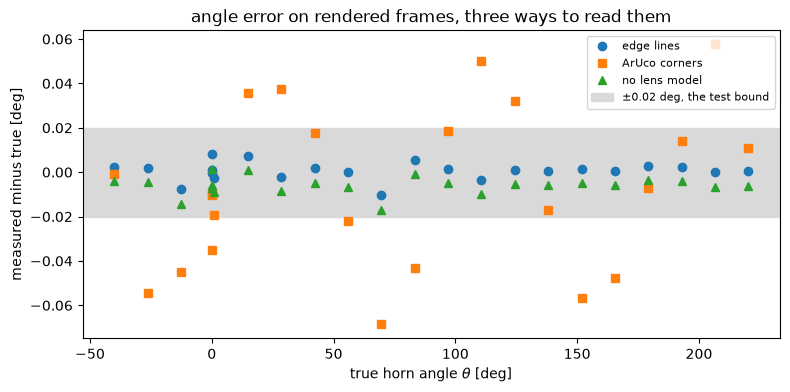

In [2]:
rend = sy.Renderer()                      # 1600 x 1200 frames, 2x2 supersampling
cam = rend.cam.camera()                   # the true lens, which section 4 recovers by calibration
flat = fd.Camera(cam.K, np.zeros(5), cam.size)   # same focal length, distortion ignored
R, t = sy.pose()                          # camera tilted 6 and -4 deg, rolled 3 deg, 230 mm away


def read_frame(img, camera, refine=True):
    # one frame -> horn angle in degrees, the two ways of getting corners
    found = fd.detect(img)
    if refine:
        horn, _ = fd.refine(img, found[fd.HORN_ID], camera)
        ref, _ = fd.refine(img, found[fd.REF_ID], camera)
    else:
        horn, ref = camera.undistort(found[fd.HORN_ID]), camera.undistort(found[fd.REF_ID])
    return fd.horn_angle(horn, ref)[0]


def wrap(d):
    # angle difference folded into -180..180
    return (np.asarray(d) + 180) % 360 - 180


TRUTH = np.round(np.concatenate([np.arange(-40, 230, 13.7), [0.05, 0.1, 0.25]]), 3)
rows = []
for i, a in enumerate(TRUTH):
    img = rend.render(sy.tag_scene(a), R, t, seed=i)
    rows.append({"true [deg]": a,
                 "edge lines": wrap(read_frame(img, cam) - a),
                 "ArUco corners": wrap(read_frame(img, cam, refine=False) - a),
                 "no lens model": wrap(read_frame(img, flat) - a)})
err = pd.DataFrame(rows).set_index("true [deg]").sort_index()
display(err.abs().agg(["mean", "max"]).T.rename(columns={"mean": "mean |error| [deg]", "max": "max |error| [deg]"}).round(4))

fig, ax = plt.subplots(figsize=(9, 4))
for col, m in zip(err.columns, "os^"):
    ax.plot(err.index, err[col], m, label=col)
ax.axhspan(-0.02, 0.02, color="0.85", label="$\\pm$0.02 deg, the test bound")
ax.set_xlabel("true horn angle $\\theta$ [deg]")
ax.set_ylabel("measured minus true [deg]")
ax.set_title("angle error on rendered frames, three ways to read them")
ax.legend(fontsize=8)
plt.show()
example = rend.render(sy.tag_scene(33.3), R, t, seed=1)

**What you are looking at.** Each dot is one rendered frame, its measured angle minus the angle it
was drawn at. The grey band is the 0.02 degree bound the tests hold the pipeline to.

The edge-line reading stays inside the band everywhere, a few thousandths of a degree off. OpenCV's
own corners wander about ten times further on average and leave the band on several frames. Their
corner refinement looks at a small window around each corner, where the two edges meet and the blur
from both mixes, while a line fit gets to use the whole length of each edge.

Leaving the lens model out costs surprisingly little here, which I did not expect. The tags sit near
the middle of the frame where barrel distortion is weakest, and the two tags sit close together, so
they get nearly the same local stretch and the reference homography takes most of it out. Section 3
moves the tags away from the middle, where that stops working.

Two honest notes. The first is about the renderer. My first version point-sampled the tag texture, and that staircases
every edge. The edge fits then came out about 0.3 pixel rms off a straight line and the angle up to
0.1 degree off. Blurring the texture to the sample spacing before sampling fixed it, which is what a
real sensor pixel does anyway, since it collects all the light that falls on it. So the numbers above
lean on the renderer being right about that, and the real capture is the actual test.

The second is about the edge fit itself. My first version estimated the paper and ink levels
separately at every sample point along the edge. With noise, a small error in those levels at one
point moves that point's edge crossing by the window width times the error, and with a blurred frame
the angle came out 0.2 degree off. Taking one paper level and one ink level per edge, and centring
the window on the edge in a second pass, fixed it.

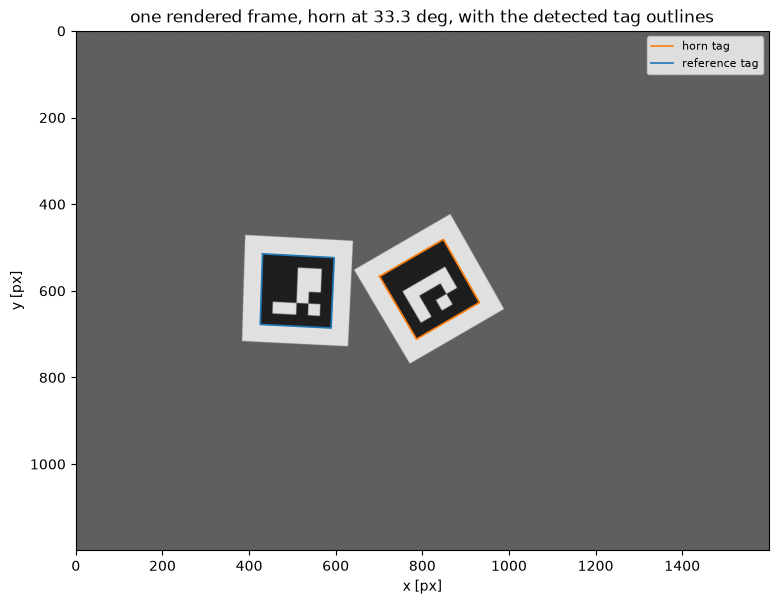

In [3]:
fig, ax = plt.subplots(figsize=(9, 6.75))
ax.imshow(example, cmap="gray", vmin=0, vmax=255)
for tid, c in fd.detect(example).items():
    c = np.vstack([c, c[:1]])
    ax.plot(c[:, 0], c[:, 1], "-", color="tab:orange" if tid == fd.HORN_ID else "tab:blue", lw=1.2,
            label="horn tag" if tid == fd.HORN_ID else "reference tag")
ax.set_title("one rendered frame, horn at 33.3 deg, with the detected tag outlines")
ax.set_xlabel("x [px]")
ax.set_ylabel("y [px]")
ax.legend(fontsize=8)
plt.show()

**What you are looking at.** A rendered frame as the pipeline gets it. The horn tag is in the middle
over the shaft, the reference tag sits to its left on the plate. The grey around them stands in for
the servo and the plate.

## 3. Where it starts to hurt

Next, the things I can't hold perfectly on the bench. The horn sits a different height above the
plate, the camera is less square to the shaft, and the frames get noisier. Every row renders the same
eight horn angles and keeps the worst error.

In [4]:
SWEEP_ANGLES = [-30.0, 5.0, 37.0, 71.0, 98.0, 133.0, 166.0, 201.0]


def worst(scene_kw=None, pose_kw=None, render_kw=None):
    # the largest |error| over the eight angles for one setting
    pr = sy.pose(**(pose_kw or {}))
    out = []
    for i, a in enumerate(SWEEP_ANGLES):
        img = rend.render(sy.tag_scene(a, **(scene_kw or {})), *pr, seed=100 + i, **(render_kw or {}))
        out.append(abs(wrap(read_frame(img, cam) - a)))
    return max(out)


rows = []
for h in (0.0, 4.0, 9.0, 16.0):
    rows.append({"what changes": "horn height above the plate", "setting": f"{h:g} mm", "worst |error| [deg]": worst({"height_mm": h})})
for tilt in ((0.0, 0.0), (6.0, -4.0), (12.0, -9.0), (20.0, 14.0)):
    rows.append({"what changes": "camera tilt off the shaft axis", "setting": f"{tilt[0]:g}, {tilt[1]:g} deg",
                 "worst |error| [deg]": worst(pose_kw={"tilt_deg": tilt})})
for n in (0.0, 1.5, 4.0, 8.0):
    rows.append({"what changes": "sensor noise", "setting": f"{n:g} grey levels rms", "worst |error| [deg]": worst(render_kw={"noise": n})})
for b in (0.6, 1.5, 3.0):
    rows.append({"what changes": "blur (focus, motion)", "setting": f"{b:g} px sigma", "worst |error| [deg]": worst(render_kw={"blur_px": b})})
display(pd.DataFrame(rows).set_index(["what changes", "setting"]).round(4))


def worst_lens(look_at, camera):
    # the same, with the camera aimed off the tags so they land toward a frame corner
    pr = sy.pose(look_at=look_at)
    out = []
    for i, a in enumerate(SWEEP_ANGLES):
        img = rend.render(sy.tag_scene(a), *pr, seed=200 + i)
        out.append(abs(wrap(read_frame(img, camera) - a)))
    return max(out)


rows = []
for look, where in (((0.0, 0.0), "middle"), ((30.0, 20.0), "a third of the way out"), ((55.0, 40.0), "near the corner")):
    rows.append({"tags in the frame": where, "with the lens model [deg]": worst_lens(look, cam),
                 "without it [deg]": worst_lens(look, flat)})
display(pd.DataFrame(rows).set_index("tags in the frame").round(4))

worst |error| [deg]
what changes                   setting                                 
horn height above the plate    0 mm                              0.0065
                               4 mm                              0.0055
                               9 mm                              0.0062
                               16 mm                             0.0067
camera tilt off the shaft axis 0, 0 deg                          0.0106
                               6, -4 deg                         0.0062
                               12, -9 deg                        0.0099
                               20, 14 deg                        0.0121
sensor noise                   0 grey levels rms                 0.0007
                               1.5 grey levels rms               0.0062
                               4 grey levels rms                 0.0146
                               8 grey levels rms                 0.0320
blur (focus, motion)           0.6 px sigma                      0.0062
                               1.5 px sigma                      0.0052
                               3 px sigma                        0.0076

,with the lens model [deg],without it [deg]
tags in the frame,,
middle,0.0058,0.0115
a third of the way out,0.0095,0.1084
near the corner,0.0103,0.1027


**What you are looking at.** The worst angle error out of eight frames for each setting. The default
setting is 9 mm, 6 and -4 degrees, 1.5 grey levels and 0.6 px.

Height and tilt barely register, which is the parallel plane argument from section 1 doing its job.
Blur barely registers either. Noise is what costs, roughly in proportion, and 8 grey levels of noise
on tags this small reaches about 0.03 degree. A frame in good light has 1 to 2. The 4K frames put
about twice as many pixels across each tag, which helps on top.

The second table aims the camera away so the tags land further out in the frame. Without the lens
model the error jumps to about 0.1 degree as soon as the tags leave the middle. With it, nothing
changes. So the calibration is cheap
insurance, and keeping the tags in the middle of the frame is free insurance on top.

What this table can't show is a horn plane that is not parallel to the plate, because the renderer
only draws parallel planes. On paper, a horn tag tipped by $\delta$ squashes its circle by $\cos\delta$
in one direction, which bends $\theta$ by up to about $\delta^2/4$ radians. That is 0.017 degree for a
2 degree tip, and it repeats twice per turn. It is a calculation, not a test, and it goes in the open
list at the end.

## 4. Calibrating the camera

The lens model comes from filming a printed ChArUco board, a chessboard with a small ArUco marker in
every white square. The markers tell OpenCV which corner is which even when part of the board is out
of frame. OpenCV's `calibrateCamera` then fits the focal length, the image centre and five distortion
terms to all the corners from all the views.

Here the views are rendered with the same lens as section 2, ten poses tilted up to about 25 degrees,
and the fit has to find that lens again.

In [5]:
board = sy.board_scene()
POSES = [((0, 0), 0, 330), ((22, 0), 5, 340), ((-22, 0), -5, 340), ((0, 24), 90, 330), ((0, -24), 85, 330),
         ((15, 15), 30, 300), ((-15, 18), -25, 310), ((18, -15), 60, 320), ((-20, -12), 100, 320), ((10, -25), -10, 300)]
rng = np.random.default_rng(7)
views = [rend.render([board], *sy.pose(tilt, roll, dist, look_at=rng.uniform(-30, 30, 2)), seed=i)
         for i, (tilt, roll, dist) in enumerate(POSES)]
fitted = fd.calibrate(views)

names = ["fx [px]", "fy [px]", "cx [px]", "cy [px]", "k1", "k2", "p1", "p2", "k3"]
true_v = [cam.K[0, 0], cam.K[1, 1], cam.K[0, 2], cam.K[1, 2], *cam.dist]
fit_v = [fitted.K[0, 0], fitted.K[1, 1], fitted.K[0, 2], fitted.K[1, 2], *fitted.dist]
display(pd.DataFrame({"true": true_v, "fitted": fit_v}, index=names).round(5))
print(f"{fitted.views} views, reprojection rms {fitted.rms_px:.3f} px")

# where the fitted lens and the true lens disagree on the undistorted position of a pixel
gx, gy = np.meshgrid(np.linspace(0, cam.size[0] - 1, 33), np.linspace(0, cam.size[1] - 1, 25))
g = np.stack([gx.ravel(), gy.ravel()], -1)
gap = np.hypot(*(fitted.undistort(g) - cam.undistort(g)).T).reshape(gx.shape)
centre = (np.abs(gx - cam.size[0] / 2) < 400) & (np.abs(gy - cam.size[1] / 2) < 300)
print(f"fitted vs true lens: {gap[centre].max():.3f} px worst over the middle half, {gap.max():.3f} px worst in the corners")

rows = []
for i, a in enumerate((-44.4, 17.2, 61.0, 150.5)):
    img = rend.render(sy.tag_scene(a), R, t, seed=50 + i)
    rows.append({"true [deg]": a, "error, fitted lens [deg]": wrap(read_frame(img, fitted) - a),
                 "error, true lens [deg]": wrap(read_frame(img, cam) - a)})
display(pd.DataFrame(rows).set_index("true [deg]").round(4))

,true,fitted
fx [px],1500.0000,1500.11589
fy [px],1500.0000,1500.12250
cx [px],813.5000,813.76950
cy [px],590.5000,590.47238
k1,-0.1100,-0.11025
k2,0.0700,0.07528
p1,0.0006,0.00057
p2,-0.0004,-0.00035
k3,0.0000,-0.01983


10 views, reprojection rms 0.032 px
fitted vs true lens: 0.036 px worst over the middle half, 1.562 px worst in the corners


,"error, fitted lens [deg]","error, true lens [deg]"
true [deg],,
-44.4,0.0083,0.0086
17.2,0.0018,0.0021
61.0,-0.0096,-0.0093
150.5,-0.0067,-0.0064


**What you are looking at.** The top table puts the fitted lens next to the one the frames were
rendered with. The bottom one reads tag frames through each.

The focal length and centre come back within a fraction of a pixel. The fit trades $k_3$ against
$k_1$ and $k_2$ a little, which only shows in the far corners of the frame where the board views
never reached. Through the middle, where the tags sit, the two lenses agree to a few hundredths of a
pixel and the angles read the same either way.

On the bench, that means the board views should fill the frame and reach into the corners, and the
tags should sit near the middle of the frame.

## 5. Lining up the video clock with the osc log

The video and the osc log run on two different clocks. The board's DATA lamp is the link between
them. It is a blue LED that lights while the bus line is low, so it glows while there is traffic and
stays dark when the bus is quiet. The bench script plays a pattern on it at the start and at the end
of the run, three half-second bursts of back to back register reads with half a second of quiet
between, and logs when each burst started on the host clock.

`fd.lamp_trace` reads the lamp's blue level in a small box around it on every frame. `fd.bursts`
finds the stretches where it stands clear of the resting level, and `fd.fit_clock` fits
video time = offset + rate x log time through the six onsets. Here it runs on a made-up 59.94 fps
trace with a known offset and a clock that runs 200 ppm fast.

6 bursts found, offset 3.2214 s (planted 3.217), rate 1.000167 (planted 1.0002), rms 0.5 ms against a 16.7 ms frame


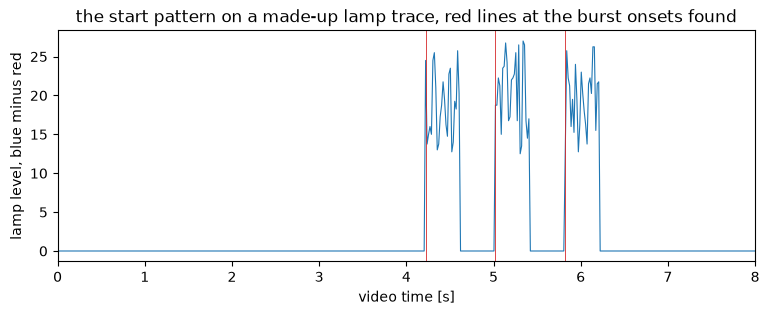

In [6]:
FPS, OFFSET, RATE = 59.94, 3.217, 1.0002
log_on = np.array([1.0, 1.8, 2.6, 61.0, 61.8, 62.6])     # host times the bursts started [s]
tv = np.arange(0, 70, 1 / FPS)                            # video frame times [s]
lit = np.zeros_like(tv, bool)
for on in OFFSET + RATE * log_on:
    lit |= (tv >= on) & (tv < on + 0.4)
rng = np.random.default_rng(3)
frames = []
for i, ti in enumerate(tv):
    img = np.full((12, 12, 3), 40, np.uint8)                # a dark box around the lamp
    if lit[i]:
        img[3:9, 3:9, 0] = 90 + rng.integers(0, 60)         # the lamp, brightness varying per frame
    frames.append((i, ti, img))
trace = fd.lamp_trace(frames, (0, 0, 12, 12))
found = fd.bursts(trace["t"], trace["level"])
off, rate, rms = fd.fit_clock(found["on"], log_on)
print(f"{len(found)} bursts found, offset {off:.4f} s (planted {OFFSET}), rate {rate:.6f} (planted {RATE}), "
      f"rms {rms * 1e3:.1f} ms against a {1e3 / FPS:.1f} ms frame")

fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(trace["t"], trace["level"], lw=0.8)
for on in found["on"]:
    ax.axvline(on, color="tab:red", lw=0.6)
ax.set_xlim(0, 8)
ax.set_xlabel("video time [s]")
ax.set_ylabel("lamp level, blue minus red")
ax.set_title("the start pattern on a made-up lamp trace, red lines at the burst onsets found")
plt.show()

**What you are looking at.** The lamp level over the first 8 seconds of the made-up trace, with the
three start bursts. The fit lands within one frame, which is as good as onsets can be read at 60 fps.

I don't know yet how bright the real lamp gets. A bus transaction takes well under a millisecond and
each `osc read` costs a whole process start on the host, so during a burst the line is busy only a few
percent of the time. A frame catches the lamp lit only when its exposure overlaps a transaction. If
the bursts don't show, there is a second way to line up the clocks. `fd.align_by_motion` slides the
logged pot trace along the video angle until their steps match. Section 6 runs both and compares
them.

## 6. The real capture (waiting for it)

The capture lands in `telemetry/mg90-a__dev-v006-2A__2s__fiducial/`. The videos are too big for
git and stay outside it. What gets checked in is what comes out of them:

```
telemetry/mg90-a__dev-v006-2A__2s__fiducial/
  camera.json             the lens, from the board video
  holds/angles.csv        one row per frame of the holds video, fd.track + fd.angles
  holds/lamp.csv          the lamp trace of the holds video
  holds/log.csv           the bench script's poll log
  holds/events.csv        its goal writes and sync bursts
  holds/dump.txt          the control table at the start (cal's stops and travel)
  steps/...               the same for the slow motion step run
```

To build those from the videos, point `FIDUCIAL_VIDEO` at the folder holding `board.mov`,
`holds.mov` and `steps.mov`, set `LAMP_ROI` to the box around the DATA lamp in pixels, and run the
next cell. It takes a few minutes per minute of 4K video.

Until the files exist, every cell below runs on a **DRY RUN** stand-in. It is made from the real pot
table and the real cal numbers, with a planted travel error, a planted pot wiggle and a planted lash,
so I can see the grading code find them. None of its numbers are measurements.

In [7]:
DATA = Path("telemetry/mg90-a__dev-v006-2A__2s__fiducial")
VIDEO = os.environ.get("FIDUCIAL_VIDEO")
LAMP_ROI = (0, 0, 16, 16)          # x, y, w, h of the DATA lamp in the video frames, set from a frame
# the caliper readings of the 50.00 mm check squares, page X then Y, one pair per tag
HORN_SCALE = fd.PrintScale(50.00, 50.00)
REF_SCALE = fd.PrintScale(50.00, 50.00)

if VIDEO and not (DATA / "holds" / "angles.csv").exists():
    v = Path(VIDEO)
    lens = fd.calibrate(f for _, _, f in fd.video_frames(v / "board.mov", step=15))
    DATA.mkdir(parents=True, exist_ok=True)
    lens.save(DATA / "camera.json")
    print(f"lens: {lens.views} views, rms {lens.rms_px:.3f} px")
    for run in ("holds", "steps"):
        (DATA / run).mkdir(exist_ok=True)
        tr = fd.track(fd.video_frames(v / f"{run}.mov"), lens)
        fd.angles(tr, HORN_SCALE, REF_SCALE).to_csv(DATA / run / "angles.csv", index=False)
        fd.lamp_trace(fd.video_frames(v / f"{run}.mov"), LAMP_ROI).to_csv(DATA / run / "lamp.csv", index=False)
REAL = (DATA / "holds" / "angles.csv").exists()
print("real capture" if REAL else "no capture yet: section 6 is a DRY RUN on made-up numbers")

no capture yet: section 6 is a DRY RUN on made-up numbers


In [8]:
def dry_run_holds(seed=0):
    # a stand-in for holds/log.csv, events.csv and angles.csv, built the way the bench script and
    # the video would build them, with three planted errors to find
    rng = np.random.default_rng(seed)
    plant = {"travel_scale": 1.008, "wiggle_deg": 0.25, "lash_deg": 0.12, "offset_deg": 31.0}
    targets = np.round(np.linspace(600, 3400, 15)).astype(int)
    log, ev, t = [], [], 4.0
    for tg in targets:
        for approach, sgn in (("up", 1), ("down", -1)):
            held = tg - sgn * rng.uniform(2, 9)                        # the loop parks short of the goal
            ev.append({"t": t, "kind": "hold", "target": tg, "approach": approach})
            for k in range(60):
                log.append({"t": t + k * 0.035, "phase": "hold", "target": tg, "approach": approach,
                            "goal": tg, "pos": round(held + rng.normal(0, 0.6))})
            t += 2.1 + 1.3
    log = pd.DataFrame(log)
    ev = pd.DataFrame(ev)
    # the true horn angle: cal's degrees of the linearized pot, a travel error, a slow wiggle the
    # table does not know about, and lash between pot and horn that changes sign with approach
    lin = LUT.counts(log["pos"].round().astype(int).to_numpy())
    truth = (plant["offset_deg"] + plant["travel_scale"] * cal_deg(lin)
             + plant["wiggle_deg"] * np.sin(2 * np.pi * lin / 1400)
             + np.where(log["approach"] == "up", -0.5, 0.5) * plant["lash_deg"])
    # the video: 30 fps on its own clock, 2.5 s ahead and 100 ppm fast
    tv = np.arange(0, log["t"].max() + 8, 1 / 30)
    ang = np.interp((tv - 2.5) / 1.0001, log["t"], truth) + rng.normal(0, 0.01, len(tv))
    angles = pd.DataFrame({"frame": np.arange(len(tv)), "t": tv, "angle_deg": ang})
    sync = pd.DataFrame({"kind": "sync", "on": [0.1, 1.1, 2.1, t + 1, t + 2, t + 3]})
    return log, pd.concat([ev, sync], ignore_index=True), angles, sync["on"].to_numpy() * 1.0001 + 2.5, plant


def read_dump(path):
    # `osc dump` lines read "name = value  (addr ...)"
    out = {}
    for line in path.read_text().splitlines():
        name, eq, rest = line.partition(" = ")
        if eq:
            out[name.strip()] = rest.split("  (")[0].strip()
    return out


if REAL:
    dump = read_dump(DATA / "holds" / "dump.txt")
    num = {k: float(dump[k].split()[0]) for k in ("raw_min", "raw_max", "angle_min_cdeg", "angle_max_cdeg", "gear_ratio_centi")}
    CAL = {"raw_min": int(num["raw_min"]), "raw_max": int(num["raw_max"]),
           "travel_deg": (num["angle_max_cdeg"] - num["angle_min_cdeg"]) / 100, "gear_ratio": num["gear_ratio_centi"] / 100}
    print(f"cal from the capture's dump: {CAL}")
    if (LUT_STOPS["raw_min"], LUT_STOPS["raw_max"]) != (CAL["raw_min"], CAL["raw_max"]):
        print("the table under test was built on other stops than the servo held during the capture")
    LOG = pd.read_csv(DATA / "holds" / "log.csv")
    EV = pd.read_csv(DATA / "holds" / "events.csv")
    ANG = pd.read_csv(DATA / "holds" / "angles.csv")
    lamp = pd.read_csv(DATA / "holds" / "lamp.csv")
    VIDEO_ON = fd.bursts(lamp["t"], lamp["level"])["on"].to_numpy()
    PLANT = None
else:
    LOG, EV, ANG, VIDEO_ON, PLANT = dry_run_holds()
TAG = "" if REAL else "DRY RUN: "

log_on = EV.loc[EV["kind"] == "sync", "on"].to_numpy()
offset, rate, rms = fd.fit_clock(VIDEO_ON, log_on)
moff, corr = fd.align_by_motion(ANG["t"], ANG["angle_deg"], LOG["t"], LOG["pos"], search_s=6.0, rate=rate)
print(f"{TAG}lamp sync: video = {offset:.3f} s + {rate:.6f} x log, rms {rms * 1e3:.1f} ms")
print(f"{TAG}motion sync: offset {moff:.3f} s (correlation {corr:.3f}), {abs(moff - offset) * 1e3:.0f} ms from the lamp")

DRY RUN: lamp sync: video = 2.500 s + 1.000100 x log, rms 0.0 ms
DRY RUN: motion sync: offset 2.500 s (correlation 0.957), 0 ms from the lamp


**What you are looking at.** The two clock fits. The lamp gives the offset and the rate, the motion
match gives a second offset to check it against. On the real capture, if they disagree by more than
a frame or two, the burst matching is wrong and the motion sync is the one to trust.

In [9]:
SETTLED_S = 1.0          # the last second of each 2 s hold, after the loop has parked


def hold_table(log, ang, offset, rate):
    # one row per hold: the pot over its last second, and the video angle over the same window
    rows = []
    for (tg, ap), g in log[log["phase"] == "hold"].groupby(["target", "approach"]):
        g = g[g["t"] >= g["t"].max() - SETTLED_S]
        v0, v1 = offset + rate * g["t"].min(), offset + rate * g["t"].max()
        w = ang[(ang["t"] >= v0) & (ang["t"] <= v1)]["angle_deg"]
        rows.append({"target": tg, "approach": ap, "pos": g["pos"].median(), "pos sd": g["pos"].std(),
                     "frames": len(w), "video [deg]": w.median(), "video sd [deg]": w.std()})
    h = pd.DataFrame(rows)
    h["cal raw [deg]"] = cal_deg(h["pos"])
    h["cal table [deg]"] = cal_deg(LUT.counts(h["pos"].round().astype(int).to_numpy()))
    return h


H = hold_table(LOG, ANG, offset, rate)
print(f"{TAG}{len(H)} holds, {H['frames'].min()} to {H['frames'].max()} frames each, "
      f"video sd {H['video sd [deg]'].median():.3f} deg median, pot sd {H['pos sd'].median():.2f} counts median")

DRY RUN: 30 holds, 29 to 30 frames each, video sd 0.031 deg median, pot sd 0.68 counts median


### 6.1 Grading cal's degrees and the table

The video angle has its own zero, wherever the horn tag happened to be glued, and it may count the
other way round. So the grade is a straight line fit, video = $a$ + $s$ x cal degrees. If cal's
travel is right, $|s|$ is 1. Whatever is left after the line is the shape error, which is what the
table is supposed to remove. Both approaches go into the fit, and their average cancels the lash.

,slope s,travel it implies [deg],residual rms [deg],residual peak to peak [deg]
pot through,,,,
cal raw [deg],1.0223,187.5993,1.0481,3.7619
cal table [deg],1.0093,185.1976,0.1762,0.6355


DRY RUN planted: travel 184.97 deg, wiggle +/-0.25 deg, lash 0.12 deg


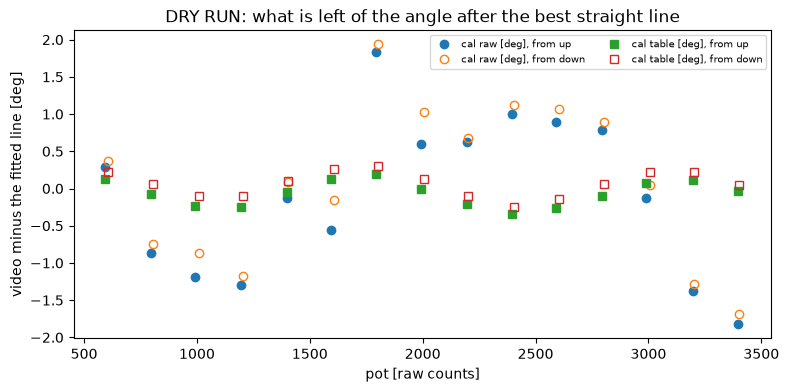

In [10]:
def grade(h, col):
    # slope, offset and what is left after the line, for one way of turning pot counts into degrees
    s, a = np.polyfit(h[col], h["video [deg]"], 1)
    resid = h["video [deg]"] - (a + s * h[col])
    return s, a, resid


rows, RES = [], {}
for col in ("cal raw [deg]", "cal table [deg]"):
    s, a, resid = grade(H, col)
    RES[col] = resid
    rows.append({"pot through": col, "slope s": s, "travel it implies [deg]": abs(s) * CAL["travel_deg"],
                 "residual rms [deg]": resid.std(), "residual peak to peak [deg]": np.ptp(resid)})
display(pd.DataFrame(rows).set_index("pot through").round(4))
if PLANT:
    print(f"DRY RUN planted: travel {PLANT['travel_scale'] * CAL['travel_deg']:.2f} deg, "
          f"wiggle +/-{PLANT['wiggle_deg']} deg, lash {PLANT['lash_deg']} deg")

fig, ax = plt.subplots(figsize=(9, 4))
for col, m in zip(RES, "os"):
    for ap, fill in (("up", "full"), ("down", "none")):
        k = H["approach"] == ap
        ax.plot(H.loc[k, "pos"], RES[col][k], m, fillstyle=fill, label=f"{col}, from {ap}")
ax.set_xlabel("pot [raw counts]")
ax.set_ylabel("video minus the fitted line [deg]")
ax.set_title(f"{TAG}what is left of the angle after the best straight line")
ax.legend(fontsize=7, ncol=2)
plt.show()

**What you are looking at.** One point per hold, the video angle minus the best line through cal's
degrees. Circles are the raw pot, squares are the pot through the table. Filled points came from
below, open ones from above. If the table does its job, the squares lie flatter than the circles. The
vertical gap between filled and open points at the same target is the lash between pot and horn.

In [11]:
lash = (H.pivot(index="target", columns="approach", values="video [deg]")
        - H.pivot(index="target", columns="approach", values="cal table [deg]").mul(grade(H, "cal table [deg]")[0]))
lash = (lash["down"] - lash["up"]).rename("down minus up [deg]")
park = H.assign(miss=H["pos"] - H["target"]).pivot(index="target", columns="approach", values="miss")
out = pd.concat([lash, park.rename(columns={"up": "pot - goal, from up", "down": "pot - goal, from down"})], axis=1)
display(out.round(3).T)
print(f"{TAG}lash between pot and horn: {lash.mean():+.3f} deg mean, {lash.std():.3f} sd over {len(lash)} targets")

target,600,800,1000,1200,1400,1600,1800,2000,2200,2400,2600,2800,3000,3200,3400
down minus up [deg],0.089,0.141,0.136,0.153,0.143,0.14,0.105,0.123,0.102,0.097,0.119,0.157,0.142,0.11,0.083
"pot - goal, from down",4.000,4.000,7.000,4.000,3.000,6.00,2.000,4.000,2.000,4.000,2.000,2.000,8.000,2.00,3.000
"pot - goal, from up",-6.000,-4.000,-8.000,-6.000,-2.000,-8.00,-8.000,-8.000,-5.000,-6.000,-9.000,-7.000,-9.000,-3.00,-3.000


DRY RUN: lash between pot and horn: +0.123 deg mean, 0.024 sd over 15 targets


**What you are looking at.** The first row is the lash. At each target it is the video angle
approached from above minus from below, after taking out where the pot itself parked. The pot is on
the output shaft, so this is the slop between the pot's coupling and the horn, not the gear lash. The
gear lash shows up in the other two rows instead, where the loop parks the pot short of the goal from
each side.

### 6.2 Step dynamics

The slow motion run is six goal steps of 200 and 400 counts about centre. Each step's onset comes from
the event log through the clock fit, and the video angle after it gives rise time, overshoot and
settling. The stand-in is a made-up second order response, there only to run the code.

In [12]:
def step_metrics(ang, onsets, sizes, window_s=1.2):
    # rise 10-90%, overshoot and 2% settling of the video angle after each step onset
    rows = []
    for t0, size in zip(onsets, sizes):
        w = ang[(ang["t"] >= t0 - 0.05) & (ang["t"] <= t0 + window_s)]
        before = w[w["t"] < t0]["angle_deg"].median()
        y = (w["angle_deg"] - before).to_numpy()
        tt = w["t"].to_numpy() - t0
        final = np.median(y[tt > window_s - 0.3])
        n = y / final
        t10, t90 = tt[np.argmax(n >= 0.1)], tt[np.argmax(n >= 0.9)]
        out_of_band = np.flatnonzero(np.abs(n - 1) > 0.02)
        rows.append({"step [counts]": size, "final [deg]": final, "rise 10-90 [ms]": (t90 - t10) * 1e3,
                     "overshoot [%]": max(0.0, (n.max() - 1) * 100),
                     "settle 2% [ms]": tt[out_of_band[-1]] * 1e3 if len(out_of_band) else 0.0})
    return pd.DataFrame(rows)


if (DATA / "steps" / "angles.csv").exists():
    SANG = pd.read_csv(DATA / "steps" / "angles.csv")
    sev = pd.read_csv(DATA / "steps" / "events.csv")
    slamp = pd.read_csv(DATA / "steps" / "lamp.csv")
    so, sr, _ = fd.fit_clock(fd.bursts(slamp["t"], slamp["level"])["on"], sev.loc[sev["kind"] == "sync", "on"])
    st = sev[sev["kind"] == "step"]
    ONSETS, SIZES = so + sr * st["t"].to_numpy(), st["size"].to_numpy()
else:
    SIZES = np.array([200, -200, 400, -400, 200, -200])
    ONSETS = 1.0 + 1.5 * np.arange(len(SIZES))
    ts = np.arange(0, ONSETS[-1] + 1.6, 1 / 240)                 # 240 fps
    wn, zeta = 2 * np.pi * 9.0, 0.6
    ang = np.zeros_like(ts)
    level = 0.0
    for t0, s in zip(ONSETS, SIZES):
        tau = np.clip(ts - t0, 0, None)
        wd = wn * np.sqrt(1 - zeta ** 2)
        resp = 1 - np.exp(-zeta * wn * tau) * (np.cos(wd * tau) + zeta / np.sqrt(1 - zeta ** 2) * np.sin(wd * tau))
        ang += np.where(ts >= t0, s / 19.3 * resp, 0.0)
    SANG = pd.DataFrame({"t": ts, "angle_deg": ang + np.random.default_rng(4).normal(0, 0.01, len(ts))})
display(step_metrics(SANG, ONSETS, SIZES).round(2).set_index("step [counts]"))
print(f"{TAG}step metrics")

,final [deg],rise 10-90 [ms],overshoot [%],settle 2% [ms]
step [counts],,,,
200,10.36,29.17,9.46,104.17
-200,-10.36,29.17,9.43,104.17
400,20.72,29.17,9.45,104.17
-400,-20.73,29.17,9.43,104.17
200,10.36,29.17,9.50,104.17
-200,-10.36,29.17,9.45,104.17


DRY RUN: step metrics


**What you are looking at.** One row per step. On the real capture, the onset is the goal write on
the host clock, so it carries the osc round trip and the clock fit, about one frame at 240 fps. The
rise and settle times don't care about that, the overshoot doesn't either.

## Caveats

- **Everything above section 6 is rendered.** The renderer draws ideal flat paper, an ideal
  pinhole camera with OpenCV's own distortion model, and Gaussian noise. A phone does its own
  processing on top (sharpening, noise reduction, maybe lens correction and stabilization), and the
  printed edges are not perfectly straight. The 0.02 degree bound is for the method. The capture will
  say what the bench adds to it.
- **Noise is the limit.** Section 3 shows noise, not blur or tilt, sets the error. A dim scene makes
  the phone raise its gain, so bright, even light on the tags matters more than any camera setting.
- **Tag size.** The rendered tags are about 170 pixels across. In 4K at about 20 cm they should come
  out near 300, and in the 1080p slow motion frames near 150. The slow motion run is graded on
  timing, so a coarser angle is fine there.
- **The pot table drifts.** Notebook 12 found the table moving by 0.7 to 1.7 counts rms between
  captures over a session (0.04 to 0.09 degree). So grading the table to 0.05 degree only means
  something if the video holds run close in time to a table build. A fresh `osc lut build` session
  right before or after the filmed run would pin that down.
- **Rolling shutter.** The phone reads its sensor row by row. During the holds nothing moves and it
  does not matter. During the step run the horn turns while the frame is read out, and the tag's
  edges bend a little. That is a timing error of a few ms at most, under one 240 fps frame.
- **The lamp may be too dim.** See section 5. The motion sync is there as the fallback.

## Open

- **Is the bench as good as the renderer?** The renderer says a few thousandths of a degree. The
  first capture answers it with the holds themselves. The spread of the video angle over a 1 s hold
  (`video sd` in section 6) is the noise floor, and the up and down approaches to the same target,
  minutes apart, show repeatability. If the spread is far above 0.01 degree, either the phone's
  processing or the print is the cause. Filming the same holds once more with a printed tag on stiff
  card instead of paper separates the two: print flaws stay, the phone's frame to frame noise goes.
- **Does a tipped horn bend the angle?** Section 3 puts it at $\delta^2/4$, untested. Shim one side of
  the horn tag by 0.5 mm (about 1 degree over 25 mm) and film the same holds. A tip error repeats twice
  per turn and has a known size. Glue or flatness noise does not repeat.
- **Does cal's travel hold up?** That is the point of the whole notebook, and the capture answers it.
  Section 6.1's slope against cal's 183.5 degrees says yes or no.